In [1]:
%%capture
%pip install -q --upgrade -r requirements.txt


In [2]:
%pip install --upgrade "kaleido>=1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kaleido]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
pd.set_option('display.max_rows', 10)
pd.set_option('display.min_rows', 10)
import numpy as np
from scipy.stats import iqr
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"
pio.renderers.default = "png"
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap
import warnings

In [4]:
# Load the dataset
file_path = "data/processed/medicare_acs_analysis.csv"
analysis_df = pd.read_csv(file_path, dtype={"fips": str}) # read fips as a string so the leading zeros are preserved

In [5]:
analysis_df.dtypes

fips                               str
county_name                        str
avg_annual_om_beneficiaries    float64
avg_age                        float64
female_pct                     float64
                                ...   
outpatient_visits_per_1000     float64
er_visits_per_1000             float64
median_household_income        float64
poverty_rate                   float64
bachelors_or_higher_pct        float64
Length: 12, dtype: object

In [6]:
utilization_cols = ['inpatient_stays_per_1000', 'outpatient_visits_per_1000', 'er_visits_per_1000']

In [7]:
analysis_df.shape

(3134, 12)

In [8]:
analysis_df['fips'].nunique()

3134

The dataset contains 3,134 counties with each row corresponding to a U.S. county.

## Handling Missing Values

In [9]:
# Check for missing values
analysis_df.isna().sum()

fips                           0
county_name                    0
avg_annual_om_beneficiaries    1
avg_age                        1
female_pct                     3
                              ..
outpatient_visits_per_1000     2
er_visits_per_1000             3
median_household_income        1
poverty_rate                   0
bachelors_or_higher_pct        0
Length: 12, dtype: int64

In [10]:
analysis_df.isna().any(axis=1).sum()

np.int64(5)

There are missing values for only five counties. Dropping these records is a negligible loss of ~0.16% of the dataset, leaving 3,129 complete cases.

We choose complete-case deletion over imputation because suppressed CMS records represent missing measurements, and imputing them risks introducing synthetic noise into our summary statistics, correlations, and model estimates.

In [11]:
# Drop rows with missing values
analysis_df = analysis_df.dropna()

In [12]:
analysis_df.shape

(3129, 12)

In [13]:
analysis_df['fips'].nunique()

3129

## Descriptive Analysis

To analyze how inpatient, outpatient, and emergency department utilization rates vary geographically, we computed summary statistics (i.e., mean, median, interquartile range, standard deviation) and generated county-level choropleth maps across all three care settings.

In [14]:
summary_stats = analysis_df[utilization_cols].describe()
summary_stats

,inpatient_stays_per_1000,outpatient_visits_per_1000,er_visits_per_1000
count,3129.000000,3129.000000,3129.000000
mean,215.479712,5451.299407,588.512166
std,41.105920,2206.735537,107.848809
min,91.377316,915.341543,49.339544
25%,187.500004,3710.753226,522.361478
50%,215.258374,5122.816159,589.200674
75%,241.218527,6844.663557,657.162140
max,496.212128,13988.443967,1149.651062


In [15]:
for col in utilization_cols:
  print(col)
  print(f'-  Mean: {summary_stats.loc['mean', col]}')
  print(f'-  Median: {summary_stats.loc['50%', col]  }')
  print(f'-  Std Dev: {summary_stats.loc['std', col]}')
  print(f'-  IQR: {summary_stats.loc['75%', col] - summary_stats.loc['25%', col]}\n')

inpatient_stays_per_1000
-  Mean: 215.47971246132215
-  Median: 215.25837351212343
-  Std Dev: 41.10591996171189
-  IQR: 53.71852294597255

outpatient_visits_per_1000
-  Mean: 5451.299406859644
-  Median: 5122.8161585136895
-  Std Dev: 2206.735537406361
-  IQR: 3133.910331311811

er_visits_per_1000
-  Mean: 588.5121662634278
-  Median: 589.2006744875562
-  Std Dev: 107.84880897944801
-  IQR: 134.80066182709982



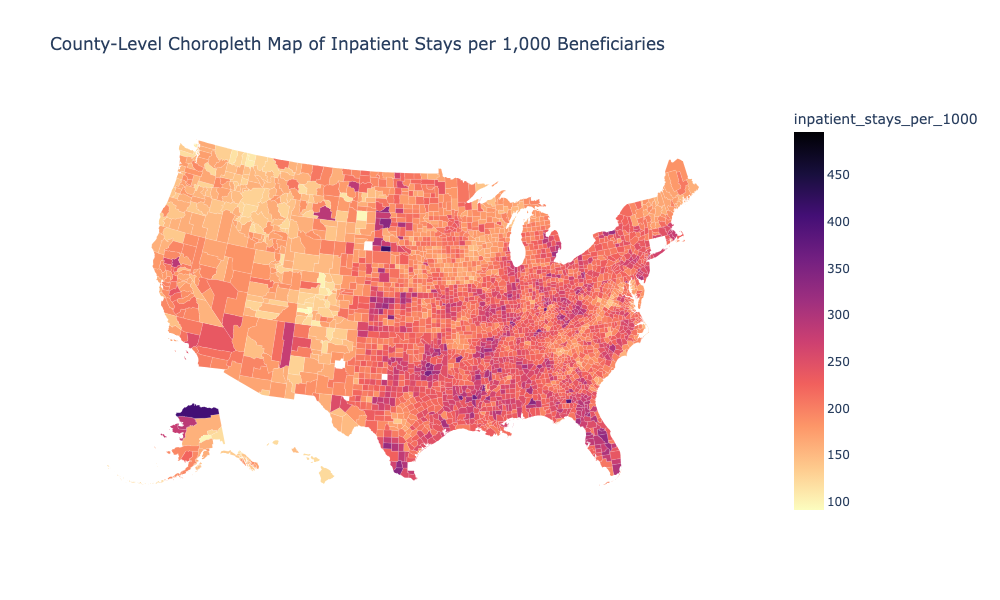

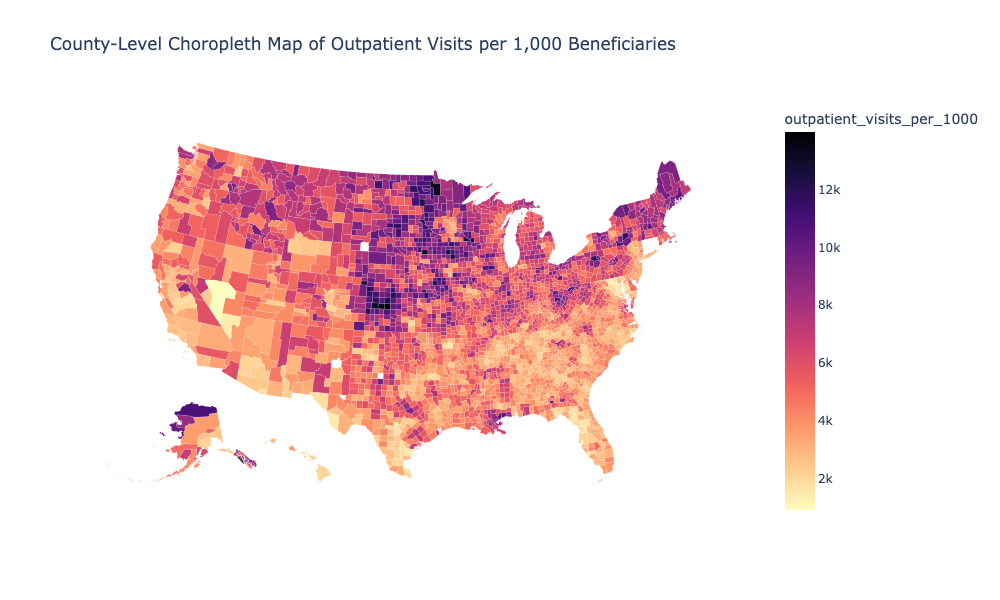

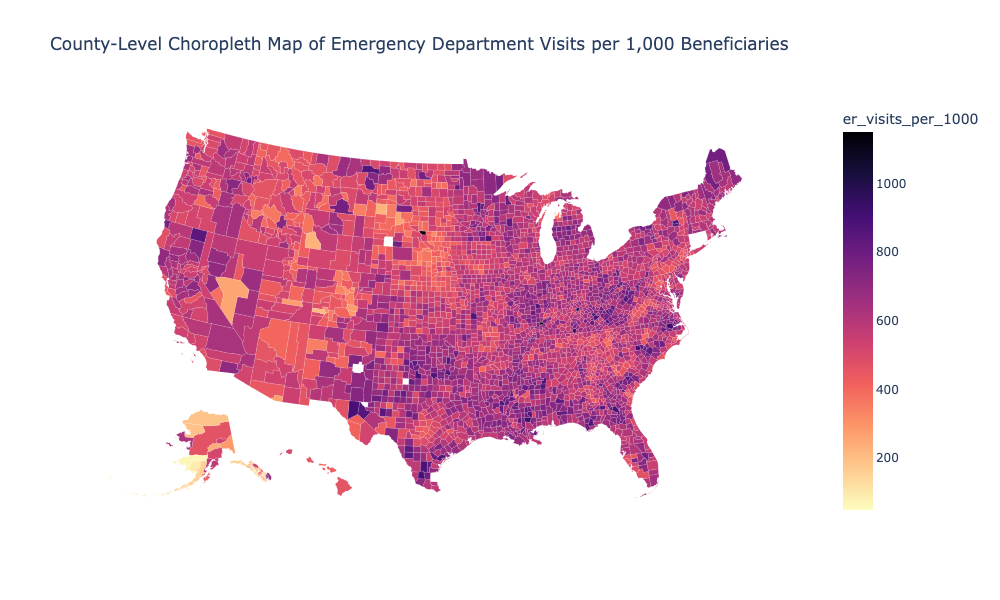

In [16]:
# Generate a county-level choropleth map for each care setting
titles = {'inpatient_stays_per_1000': 'Inpatient Stays per 1,000 Beneficiaries',
          'outpatient_visits_per_1000': 'Outpatient Visits per 1,000 Beneficiaries',
          'er_visits_per_1000': 'Emergency Department Visits per 1,000 Beneficiaries'}
for col in utilization_cols:
    fig = px.choropleth(
        analysis_df,
        geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
        locations='fips',
        color=col,
        color_continuous_scale="Magma_r", # (color-blind friendly and intuitive)
        scope="usa",
        title=f"County-Level Choropleth Map of {titles[col]}",
        width=1000,
        height=600
    )

    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_traces(marker_line_width=0.2, marker_line_color="rgba(255, 255, 255, 0.5)")  # lighten border lines 

    fig.show()

Across all 3,129 complete county cases, Medicare healthcare utilization exhibits distinct distributional shapes, levels of dispersion, and spatial patterns depending on the care setting:

#### 1. Inpatient Stays (`inpatient_stays_per_1000`)
* **Distribution & Dispersion:** Shows a symmetric, bell-shaped distribution with virtually identical central tendencies (Mean = 215.48, Median = 215.26). Dispersion is moderate, with a standard deviation of 41.11 and an IQR of 53.72 (spanning 187.50 to 241.22 stays per 1,000 beneficiaries).
* **Geographic Patterns:** Displays notable regional variation on the choropleth map. Higher utilization rates (darker red/purple shading) visually concentrate across southeastern states (such as Mississippi, Alabama, Louisiana, and parts of Florida), northern Alaska, and select isolated counties in the Midwest. Conversely, the Pacific Northwest, western mountain states, and upper Great Plains visually stand out as regions with lower utilization rates (lighter orange/yellow shading).

#### 2. Outpatient Visits (`outpatient_visits_per_1000`)
* **Distribution & Dispersion:** Exhibits a right-skewed distribution with substantial variation across counties. The mean (5,451.30 visits per 1,000) noticeably exceeds the median (5,122.82 visits per 1,000). Outpatient care demonstrates the highest relative dispersion among all three settings, with a large standard deviation of 2,206.74 and an IQR of 3,133.91 (ranging from 3,710.75 at the 25th percentile to 6,844.66 at the 75th percentile, with extreme maximums reaching nearly 14,000).
* **Geographic Patterns:** Demonstrates clear regional contrasts. Higher utilization rates visually group across the upper Midwest and northern Plains states (particularly Minnesota, Wisconsin, Iowa, and eastern parts of Nebraska and South Dakota), along with parts of the Northeast and Washington state. In contrast, southern states, Texas, and interior western states show consistently lower outpatient utilization rates.

#### 3. Emergency Department Visits (`er_visits_per_1000`)
* **Distribution & Dispersion:** Displays a near-symmetric, approximately normal distribution centered around a mean of 588.51 and a median of 589.20 visits per 1,000 beneficiaries. Dispersion is tightly bound around the center (Std Dev = 107.85, IQR = 134.80), bounded between the 25th percentile (522.36) and 75th percentile (657.16).
* **Geographic Patterns:** High ED utilization visually forms a wide, contiguous band across eastern, mid-Atlantic, and southern states (such as West Virginia, Kentucky, Ohio, and surrounding areas). Lower ED rates are visibly concentrated in central rural states and western mountain regions, highlighting geographic disparities in emergency care reliance relative to primary or outpatient access.

## Correlation Analysis

We calculated Pearson and Spearman rank correlation coefficients to quantify the linear and monotonic relationships between county-level socioeconomic factors (i.e., median household income, poverty rate, educational attainment), demographics (i.e., age, biological sex), and healthcare utilization rates.

Pearson correlations quantify linear associations, while Spearman correlations assess monotonic associations that are less sensitive to skew and outliers. Each coefficient uses pairwise-complete observations for the relevant socioeconomic, demographic, and utilization variables.

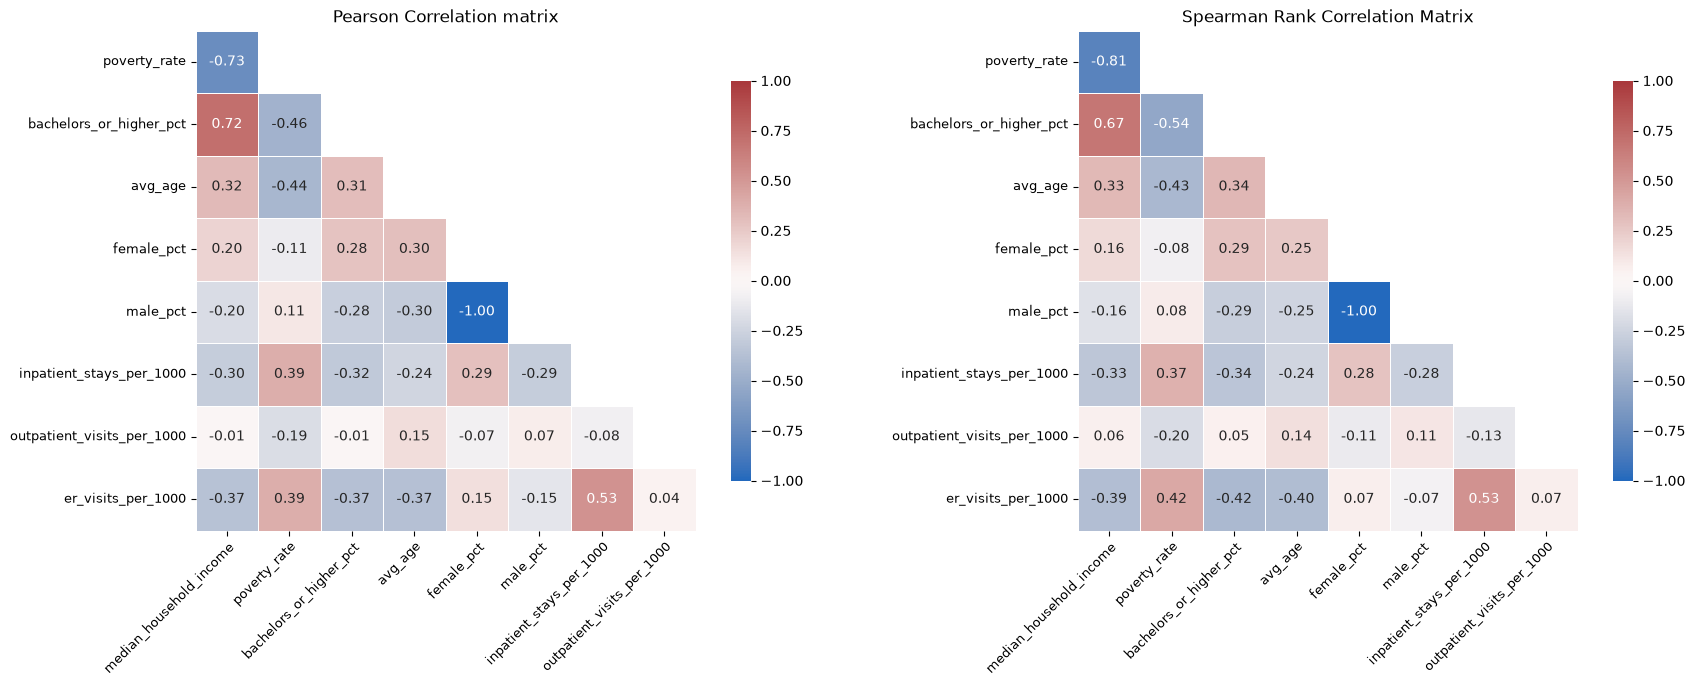

In [17]:
socioeconomic_cols = ["median_household_income", "poverty_rate", "bachelors_or_higher_pct"]
demographic_cols = ["avg_age", "female_pct", "male_pct"]
correlation_data = analysis_df[socioeconomic_cols + demographic_cols + utilization_cols]

pearson_corr = correlation_data.corr(method="pearson")
spearman_corr = correlation_data.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, matrix, title in zip(
    axes,
    (pearson_corr, spearman_corr),
    ("Pearson Correlation matrix", "Spearman Rank Correlation Matrix"),
):
    mask = np.triu(np.ones_like(matrix, dtype=bool))
    matrix_sliced = matrix.iloc[1:, :-1]
    mask_sliced = mask[1:, :-1]
    sns.heatmap(
        matrix_sliced,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax,
        mask=mask_sliced
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        rotation=45, 
        ha="right",              
        rotation_mode="anchor",
        fontsize=9
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Bivariate Correlation Assessment

* Poverty rate shows a consistent positive relationship with both ER visits ($r = 0.39$, $\rho = 0.42$) and inpatient stays ($r = 0.39$, $\rho = 0.37$).
* Median household income is negatively correlated with ER visits ($r = -0.37$, $\rho = -0.39$) and inpatient stays ($r = -0.30$, $\rho = -0.33$).
* Higher bachelor's degree attainment shows negative correlations with ER visits ($r = -0.37$, $\rho = -0.42$) and inpatient stays ($r = -0.32$, $\rho = -0.34$).
* Inpatient stays and ER visits have a moderate positive correlation with each other ($r = 0.53$, $\rho = 0.53$).
* Outpatient visits show almost no correlation with inpatient stays ($r = -0.08$, $\rho = -0.13$) or ER visits ($r = 0.04$, $\rho = 0.07$).
* Average age has a moderate negative correlation with ER visits ($r = -0.37$, $\rho = -0.40$) and inpatient stays ($r = -0.24$, $\rho = -0.24$).
* Female percentage and male percentage have a perfect negative correlation ($r = -1.00$, $\rho = -1.00$) and show minimal association with healthcare utilization rates.

## Predictive Analysis via Supervised Learning

We trained tree-based ensemble models (i.e., Random Forest, XGBoost, LightGBM) evaluated against baseline regularized linear models (i.e., Ridge and Lasso Regression) using 5-fold cross-validation evaluated via R-squared and Root Mean Squared Error (RMSE).

Each utilization outcome was modeled separately using three pre-specified predictor sets: the socioeconomic indicators alone, those indicators plus average age, and those indicators plus average age and female share. We used one 20% state-group holdout split across all feature sets and models, keeping counties from each state together, and performed five-fold `GroupKFold` cross-validation among the training states. Ridge and Lasso models standardized predictors within pipelines, so scaling was fit on each training fold; tree-based models used fixed, regularized settings. The comparison reports mean and standard deviation of cross-validation R² and RMSE, along with R² and RMSE on the held-out states. 

In [18]:
# Extract the 2-digit State FIPS code from the 5-digit County FIPS code
analysis_df["state_fips"] = analysis_df["fips"].str.zfill(5).str[:2]
states = analysis_df["state_fips"]

feature_sets = {
    "Socioeconomic": socioeconomic_cols,
    "Socioeconomic + age": socioeconomic_cols + ["avg_age"],
    # use one of female_pct or male_pct for biological sex to avoid redundancy
    "Socioeconomic + age + female share": (
        socioeconomic_cols + ["avg_age", "female_pct"]
    ),
}

# Define alpha search grid for cross-validated linear models
alpha_grid = np.logspace(-3, 3, 100)

def make_models():
    return {
        # RidgeCV & LassoCV automatically select optimal alpha via internal cross-validation
        "Ridge": make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=alpha_grid, cv=5)
        ),
        "Lasso": make_pipeline(
            StandardScaler(),
            LassoCV(alphas=alpha_grid, cv=5, max_iter=10000, random_state=42)
        ),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, max_features=1.0,
            random_state=42, n_jobs=-1,
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror", n_estimators=300, learning_rate=0.04,
            max_depth=3, min_child_weight=5, subsample=0.8,
            colsample_bytree=0.9, reg_lambda=2.0, random_state=42,
            n_jobs=-1, verbosity=0,
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=300, learning_rate=0.04, num_leaves=15,
            max_depth=-1, min_child_samples=20, reg_lambda=2.0,
            random_state=42, n_jobs=-1, verbosity=-1,
        ),
    }

# Create one state-grouped holdout split for every feature set and model
train_idx, test_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42).split(
        np.zeros((len(analysis_df), 1)),
        groups=states,
    )
)
train_groups = states.iloc[train_idx]
test_groups = states.iloc[test_idx]
cv = GroupKFold(n_splits=5)

comparison_rows = []
fitted_models = {}
holdout_predictions = {}

for feature_set_name, features in feature_sets.items():
    X = analysis_df[features]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    for target in utilization_cols:
        y = analysis_df[target]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        for model_name, estimator in make_models().items():
            cv_result = cross_validate(
                estimator,
                X_train,
                y_train,
                cv=cv,
                groups=train_groups,
                scoring={
                    "r2": "r2",
                    "rmse": "neg_root_mean_squared_error",
                },
                n_jobs=1,
                return_train_score=True,
            )

            estimator.fit(X_train, y_train)
            prediction = estimator.predict(X_test)

            comparison_rows.append({
                "Outcome": target,
                "Feature set": feature_set_name,
                "Model": model_name,
                "CV R2 mean": cv_result["test_r2"].mean(),
                "CV R2 SD": cv_result["test_r2"].std(ddof=1),
                "CV RMSE mean": -cv_result["test_rmse"].mean(),
                "CV RMSE SD": cv_result["test_rmse"].std(ddof=1),
                "Holdout R2": estimator.score(X_test, y_test),
                "Holdout RMSE": np.sqrt(
                    np.mean((y_test.to_numpy() - prediction) ** 2)
                ),
            })

            key = (target, feature_set_name, model_name)
            fitted_models[key] = estimator
            holdout_predictions[key] = (y_test, prediction)

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["Outcome", "CV RMSE mean"])
    .reset_index(drop=True)
)

display(model_comparison.round(3).head(10))

,Outcome,Feature set,Model,CV R2 mean,CV R2 SD,CV RMSE mean,CV RMSE SD,Holdout R2,Holdout RMSE
0,er_visits_per_1000,Socioeconomic + age + female share,Ridge,0.227,0.088,92.534,11.951,0.329,83.604
1,er_visits_per_1000,Socioeconomic + age + female share,Lasso,0.226,0.088,92.588,11.889,0.329,83.574
2,er_visits_per_1000,Socioeconomic + age + female share,XGBoost,0.187,0.132,94.909,14.450,0.350,82.259
3,er_visits_per_1000,Socioeconomic + age + female share,Random Forest,0.174,0.125,95.743,14.479,0.321,84.094
4,er_visits_per_1000,Socioeconomic + age + female share,LightGBM,0.167,0.110,96.080,13.402,0.336,83.150
5,er_visits_per_1000,Socioeconomic + age,Ridge,0.136,0.169,97.885,17.242,0.251,88.299
6,er_visits_per_1000,Socioeconomic + age,Lasso,0.135,0.170,97.985,17.224,0.253,88.207
7,er_visits_per_1000,Socioeconomic,Lasso,0.115,0.141,99.005,14.839,0.152,93.986
8,er_visits_per_1000,Socioeconomic,Ridge,0.114,0.141,99.080,14.878,0.151,94.060
9,er_visits_per_1000,Socioeconomic + age,XGBoost,0.087,0.188,100.583,17.780,0.297,85.556


### Predictive Model Performance and Baseline Comparison

* Out-of-sample predictive capacity varies significantly across utilization types, with emergency department visits demonstrating modest predictability while inpatient stays and outpatient visits show limited out-of-sample generalization.
* A county's socioeconomic and demographic profile provides modest predictive power for emergency room visits (`er_visits_per_1000`), peaking at a 5-fold cross-validation $R^2$ of 0.227 ($\text{RMSE} = 92.53$) for Ridge regression and a holdout $R^2$ of 0.350 ($\text{RMSE} = 82.26$) for XGBoost.
* For inpatient stays (`inpatient_stays_per_1000`), models achieve cross-validation $R^2$ values up to 0.297 ($\text{RMSE} = 33.83$), but fail to generalize to holdout test data, with holdout $R^2$ values dropping near or below zero ($0.002$ to $-0.190$).
* For outpatient visits (`outpatient_visits_per_1000`), socioeconomic profiles provide virtually no predictive signal during cross-validation, resulting in negative average cross-validation $R^2$ values across all feature sets and model algorithms.
* Non-linear tree-based ensembles (XGBoost, Random Forest, LightGBM) do not consistently outperform regularized linear baselines (Ridge and Lasso).
* Linear baselines outperform tree-based ensembles in cross-validation for emergency room visits, yielding a higher mean cross-validation $R^2$ (0.227 vs. 0.187 for XGBoost) along with lower cross-validation variance ($\text{SD} = 0.088$ vs. $0.132$).
* Non-linear models demonstrate greater vulnerability to overfitting on inpatient stays, where XGBoost achieves a higher cross-validation $R^2$ (0.297 vs. 0.280) but suffers severe holdout performance degradation ($R^2 = -0.168$ vs. $0.002$ for Lasso/Ridge).
* Expanding the feature space beyond socioeconomic status to include demographic controls substantially enhances performance, boosting cross-validation $R^2$ for emergency room visits from 0.114 to 0.227 and for inpatient stays from 0.091 to 0.280.

For each outcome, the tree model and feature set selected for SHAP interpretation were those with the lowest cross-validation RMSE among the tree ensembles; holdout results were used as a final generalization check.

In [19]:
# Select the lowest-CV-RMSE tree ensemble independently for each utilization outcome
tree_names = ["Random Forest", "XGBoost", "LightGBM"]
tree_scores = model_comparison[
    model_comparison["Model"].isin(tree_names)
]

best_tree_rows = tree_scores.loc[
    tree_scores.groupby("Outcome")["CV RMSE mean"].idxmin()
]

best_tree_by_target = {}
for _, row in best_tree_rows.iterrows():
    target = row["Outcome"]
    feature_set_name = row["Feature set"]
    model_name = row["Model"]

    best_tree_by_target[target] = {
        "model": fitted_models[(target, feature_set_name, model_name)],
        "model_name": model_name,
        "feature_set": feature_set_name,
        "features": feature_sets[feature_set_name],
    }

# Create summary table for holdout generalization check
summary_rows = []
for target, info in best_tree_by_target.items():
    model_name = info["model_name"]
    feature_set = info["feature_set"]
    row = model_comparison[
        (model_comparison["Outcome"] == target)
        & (model_comparison["Feature set"] == feature_set)
        & (model_comparison["Model"] == model_name)
    ].iloc[0]
    summary_rows.append({
        "Outcome": f"{model_name} ({target})",
        "Feature Set": feature_set,
        "CV RMSE": row["CV RMSE mean"],
        "CV R2": row["CV R2 mean"],
        "Holdout RMSE": row["Holdout RMSE"],
        "Holdout R2": row["Holdout R2"],
    })
shap_selection_summary = pd.DataFrame(summary_rows)
print("=== Selected Tree Models for SHAP Interpretation ===\n")
print(shap_selection_summary.round(3).to_string(index=False))

=== Selected Tree Models for SHAP Interpretation ===

                             Outcome                        Feature Set  CV RMSE  CV R2  Holdout RMSE  Holdout R2
        XGBoost (er_visits_per_1000) Socioeconomic + age + female share   94.909  0.187        82.259       0.350
  XGBoost (inpatient_stays_per_1000) Socioeconomic + age + female share   33.834  0.297        35.287      -0.168
XGBoost (outpatient_visits_per_1000) Socioeconomic + age + female share 2060.947 -0.028      2048.462       0.244


For each utilization outcome, we selected the tree model and predictor set with the lowest mean five-fold state-grouped CV RMSE. We evaluate the selected models on the state-grouped holdout test set as follows:
* Emergency Department Visits (`er_visits_per_1000`): Out-of-sample generalization holds up strongly on unseen states, increasing from a cross-validation $R^2$ of $0.187$ to a holdout $R^2$ of $0.350$. This confirms that the learned feature relationships are stable and portable across state lines.
* Inpatient Stays (`inpatient_stays_per_1000`): Severe out-of-state generalization failure occurs, with test set performance collapsing to a negative holdout $R^2$ ($-0.168$) despite a strong cross-validation $R^2$ ($0.297$). This highlights that tree-based feature attributions for inpatient utilization capture localized, state-level health system policies rather than nationally generalizable signals.
* Outpatient Visits (`outpatient_visits_per_1000`): Cross-validation performance indicates a lack of reliable signal ($\text{CV } R^2 = -0.028$), though holdout $R^2$ reaches $0.244$. Because cross-validation shows high regional instability, SHAP feature attributions for outpatient care should be interpreted cautiously.

## Feature Importance Analysis and Residual Analysis

We applied SHAP (SHapley Additive exPlanations) values to our top-performing models to interpret feature attribution. In addition, we computed model prediction residuals (i.e., the differences between actual and predicted values) on holdout test data to identify outlier counties.

Each selected model was refit on the training states; permutation-based SHAP values were then estimated for held-out counties, using training-state observations as the background. SHAP summary plots show the magnitude and direction of feature attributions for those counties. These attributions describe model behavior, not causal effects or validated thresholds. For the same selected models, residuals were calculated as observed minus predicted utilization on the held-out states, and the ten counties with the largest absolute residuals were reported for each outcome.


Selected tree model for er_visits_per_1000: Socioeconomic + age + female share
Mean absolute SHAP attribution: er_visits_per_1000
female_pct                 25.833
avg_age                    22.684
bachelors_or_higher_pct    22.546
poverty_rate               10.032
median_household_income     9.932


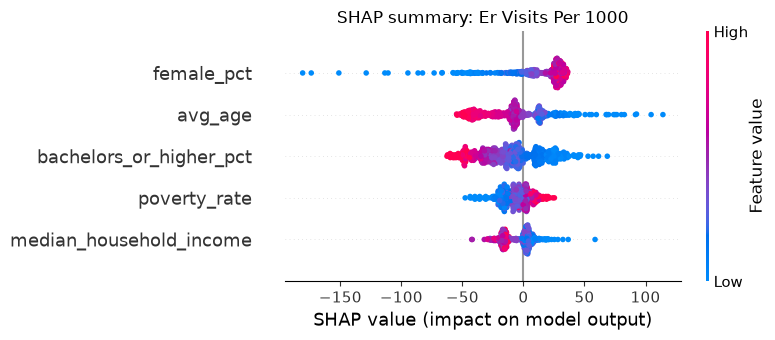


Top 10 holdout residual outliers: er_visits_per_1000
 fips        county_name  actual  predicted  residual  absolute_residual
25019       MA-Nantucket  775.65 457.589996    318.06             318.06
32023             NV-Nye  258.84 557.419983   -298.58             298.58
37015          NC-Bertie  922.31 652.159973    270.15             270.15
37007           NC-Anson  903.02 648.760010    254.26             254.26
25007           MA-Dukes  724.29 478.839996    245.45             245.45
51730 VA-Petersburg City  885.44 641.429993    244.01             244.01
31149            NE-Rock  342.60 577.950012   -235.35             235.35
37139      NC-Pasquotank  827.11 595.219971    231.89             231.89
51595    VA-Emporia City  863.33 640.280029    223.06             223.06
51620   VA-Franklin City  804.69 592.429993    212.26             212.26

Selected tree model for inpatient_stays_per_1000: Socioeconomic + age + female share
Mean absolute SHAP attribution: inpatient_stays_per_1000


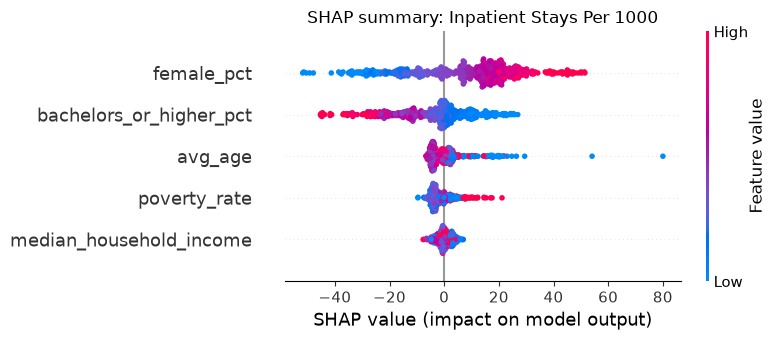


Top 10 holdout residual outliers: inpatient_stays_per_1000
 fips county_name  actual  predicted  residual  absolute_residual
53001    WA-Adams  144.59 233.860001    -89.28              89.28
53029   WA-Island  131.67 218.149994    -86.47              86.47
19051    IA-Davis  150.22 234.470001    -84.25              84.25
31091   NE-Hooker  178.74 261.709991    -82.97              82.97
31007   NE-Banner  217.39 135.789993     81.60              81.60
55043    WI-Grant  158.12 239.619995    -81.51              81.51
19143  IA-Osceola  154.54 235.100006    -80.56              80.56
31133   NE-Pawnee  165.41 243.690002    -78.28              78.28
31077  NE-Greeley  165.40 243.410004    -78.02              78.02
31037   NE-Colfax  163.65 241.479996    -77.83              77.83

Selected tree model for outpatient_visits_per_1000: Socioeconomic + age + female share
Mean absolute SHAP attribution: outpatient_visits_per_1000
median_household_income    540.598
poverty_rate               443.6

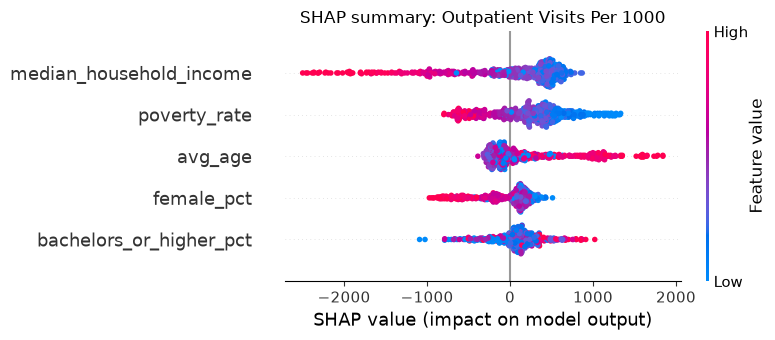


Top 10 holdout residual outliers: outpatient_visits_per_1000
 fips    county_name   actual   predicted  residual  absolute_residual
19167       IA-Sioux 13097.20 6038.680176   7058.52            7058.52
55063   WI-La Crosse 12716.75 5677.830078   7038.93            7038.93
19145        IA-Page 11896.94 5674.600098   6222.33            6222.33
19069    IA-Franklin 12697.81 7292.950195   5404.86            5404.86
25007       MA-Dukes  9610.64 4212.060059   5398.58            5398.58
19033 IA-Cerro Gordo 11118.49 5751.979980   5366.51            5366.51
19081     IA-Hancock 12487.03 7120.899902   5366.12            5366.12
19017      IA-Bremer  9774.46 4607.310059   5167.15            5167.15
19003       IA-Adams 11536.69 6393.680176   5143.01            5143.01
55045       WI-Green 10394.00 5356.729980   5037.27            5037.27


In [20]:
outlier_tables = {}

for target, best_info in best_tree_by_target.items():
    best_model = best_info["model"]
    features = best_info["features"]
    feature_set_name = best_info["feature_set"]

    X_train_shap = analysis_df.iloc[train_idx][features]
    X_test_shap = analysis_df.iloc[test_idx][features]

    # Explicitly downsample background data to 100 samples using shap.sample
    background_df = shap.sample(X_train_shap, 100, random_state=42)
    background = shap.maskers.Independent(background_df)

    def predict_from_array(values):
        values_df = pd.DataFrame(values, columns=features)
        return best_model.predict(values_df)

    explainer = shap.Explainer(
        predict_from_array,
        background,
        algorithm="permutation",
        feature_names=features,
    )
    shap_values = explainer(X_test_shap.to_numpy(), max_evals=63)

    mean_abs_shap = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=features,
    ).sort_values(ascending=False)

    print(f"\nSelected tree model for {target}: {feature_set_name}")
    print(f"Mean absolute SHAP attribution: {target}")
    print(mean_abs_shap.round(3).to_string())

    plt.figure(figsize=(9, 5))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=FutureWarning, message=".*NumPy global RNG.*")
        shap.summary_plot(
            shap_values.values,
            X_test_shap,
            feature_names=features,
            show=False,
        )
    plt.title(f"SHAP summary: {target.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()

    key = (target, feature_set_name, best_info["model_name"])
    y_test, predictions = holdout_predictions[key]

    outliers = analysis_df.iloc[test_idx][["fips", "county_name"]].copy()
    outliers["actual"] = y_test.to_numpy()
    outliers["predicted"] = predictions
    outliers["residual"] = outliers["actual"] - outliers["predicted"]
    outliers["absolute_residual"] = outliers["residual"].abs()

    outlier_tables[target] = (
        outliers.nlargest(10, "absolute_residual").reset_index(drop=True)
    )

    print(f"\nTop 10 holdout residual outliers: {target}")
    print(outlier_tables[target].round(2).to_string(index=False))

**Primary Predictive Drivers and Non-Linear Effects**
*   **Emergency Department Visits:** The female share of the population (`female_pct`, mean absolute SHAP: 25.804) and age (`avg_age`, mean absolute SHAP: 22.671) hold the strongest predictive power, closely followed by education (`bachelors_or_higher_pct`, mean absolute SHAP: 22.532). The SHAP summary plot reveals a noticeable non-linear threshold effect for poverty: while low-to-moderate poverty rates cluster near the center, high poverty rates form a trailing right tail, indicating that ED reliance increases sharply once poverty crosses a specific tipping point. Additionally, higher education consistently decreases expected ED visits.
*   **Inpatient Stays:** The female share of the population (`female_pct`, mean absolute SHAP: 18.383) and education level (`bachelors_or_higher_pct`, mean absolute SHAP: 10.860) are the primary drivers. The plot uncovers non-linear effects regarding average age, where exceptionally high age profiles are associated with markedly higher predicted inpatient utilization compared to the baseline trend.
*   **Outpatient Visits:** Economic indicators carry substantially higher predictive weight than demographic variables, led by `median_household_income` (mean absolute SHAP: 540.523) and `poverty_rate` (mean absolute SHAP: 444.633). High median household income drives a pronounced, non-linear reduction in outpatient visits, as shown by the leftward tail of negative SHAP values for higher-income communities.

#### Regional Utilization Outliers (Holdout Residuals)
* **Emergency Department Visits:** Unexpectedly high ED utilization is concentrated in Massachusetts island communities (MA-Nantucket with a top residual of +318.06, and MA-Dukes) as well as several counties across North Carolina (NC-Bertie, NC-Anson) and Virginia. Conversely, NV-Nye (-298.58) and NE-Rock (-235.35) exhibit much lower ED usage than their local socioeconomic profiles predict.
* **Inpatient Stays:** Prediction errors are heavily skewed toward unexpectedly low utilization, particularly in the Midwest and Pacific Northwest. Nine of the ten largest outliers are negative residuals, led by WA-Adams (-89.28), WA-Island, IA-Davis, and NE-Hooker. NE-Banner (+81.60) is the sole top-ten outlier exhibiting higher-than-predicted inpatient stays.
* **Outpatient Visits:** The Midwest dominates the positive outliers, indicating a severe under-prediction of outpatient care given local socioeconomic conditions. Counties in Iowa (IA-Sioux with a +7058.52 residual, IA-Page, IA-Franklin) and Wisconsin (WI-La Crosse) utilize outpatient services at extraordinarily high rates compared to the model's expectations. Notably, MA-Dukes appears again here as a significant positive outlier.

## Residual Map and Ranked Residual Chart

Using the selected tree model for each outcome, we map the **residual** (actual −
predicted) for the held-out test counties. Positive (red) means a county uses *more*
care than its socioeconomic profile predicts; negative (blue) means *less*. Clustered
residuals point to drivers **outside** our socioeconomic features (provider supply,
hospital access, Medicare Advantage penetration, state policy), which connects directly
to the omitted-variable discussion in our ethics section.

> Residuals exist only for the 20% held-out test counties from the state-grouped split,
> so the map is intentionally sparse — training-split states appear blank. Set `TARGET`
> to switch between ED, inpatient, and outpatient outcomes.

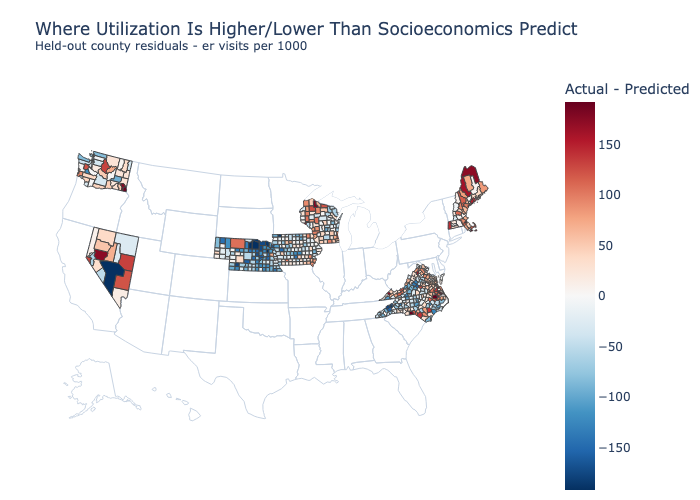

In [21]:
import plotly.express as px

# choose which utilization outcome to inspect
TARGET = "er_visits_per_1000"  # or "inpatient_stays_per_1000" / "outpatient_visits_per_1000"

# pull the selected model's held-out predictions (same keys used in the residual cell)
best_info = best_tree_by_target[TARGET]
key = (TARGET, best_info["feature_set"], best_info["model_name"])
y_test, predictions = holdout_predictions[key]

# assemble residual table for the held-out counties
resid = analysis_df.iloc[test_idx][["fips", "county_name"]].copy()
resid["actual"] = y_test.to_numpy()
resid["predicted"] = predictions
resid["residual"] = resid["actual"] - resid["predicted"]
resid["fips"] = resid["fips"].str.zfill(5)

# --- Diverging residual choropleth ---
rmax = resid["residual"].abs().quantile(0.98)  # clip extremes for balanced color
fig_map = px.choropleth(
    resid,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="residual",
    color_continuous_scale="RdBu_r",
    range_color=(-rmax, rmax),
    scope="usa",
    hover_name="county_name",
    hover_data={"actual": ":.0f", "predicted": ":.0f", "residual": ":.0f", "fips": False},
    labels={"residual": "Actual - Predicted"},
    title=(f"Where Utilization Is Higher/Lower Than Socioeconomics Predict<br>"
           f"<sup>Held-out county residuals - {TARGET.replace('_', ' ')}</sup>"),
)
fig_map.update_layout(margin=dict(l=0, r=0, t=70, b=0))
fig_map.show()

The map shows *where*; the chart below names *which* counties have the largest positive and negative residuals.

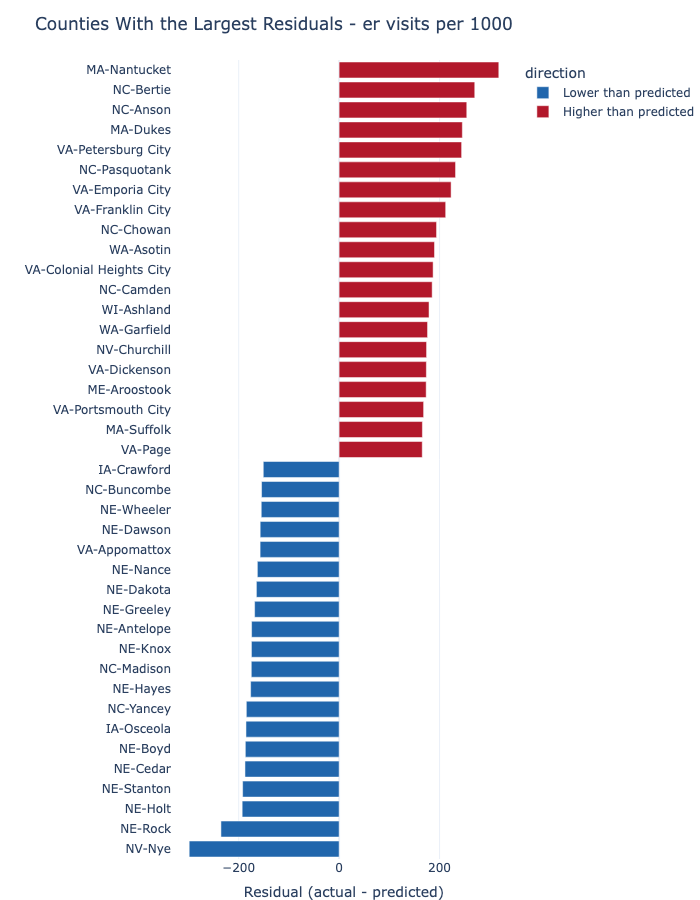

In [22]:
# --- Ranked residual bar: 20 largest positive + 20 largest negative ---
top_pos = resid.nlargest(20, "residual")
top_neg = resid.nsmallest(20, "residual")
ranked = pd.concat([top_neg, top_pos]).sort_values("residual")
ranked["direction"] = np.where(
    ranked["residual"] >= 0, "Higher than predicted", "Lower than predicted"
)

fig_bar = px.bar(
    ranked,
    x="residual", y="county_name", color="direction", orientation="h",
    color_discrete_map={"Higher than predicted": "#B2182B",
                        "Lower than predicted": "#2166AC"},
    labels={"residual": "Residual (actual - predicted)", "county_name": ""},
    title=f"Counties With the Largest Residuals - {TARGET.replace('_', ' ')}",
)
fig_bar.update_layout(
    height=900, margin=dict(l=0, r=0, t=60, b=0),
    yaxis={"categoryorder": "array", "categoryarray": ranked["county_name"].tolist()},
)
fig_bar.show()